In [1]:
# ============================================================
# FUNCTION 1 — WEEK 5 CLEAN REBUILD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    WhiteKernel,
    ConstantKernel as C
)

# ------------------------------------------------------------
# 1. Load the original Function 1 data
# ------------------------------------------------------------

X = np.load("function1/initial_inputs.npy")
Y = np.load("function1/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–4 exactly once
# ------------------------------------------------------------

week1_x = np.array([[0.737954, 0.758348]])
week1_y = np.array([-2.857650951335033e-21])

week2_x = np.array([[0.773956, 0.438878]])
week2_y = np.array([9.656222973626152e-41])

week3_x = np.array([[0.676583, 0.811941]])
week3_y = np.array([-3.592807837147156e-26])

week4_x = np.array([[0.615097, 1.000000]])
week4_y = np.array([-1.1193558896664302e-96])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x,
    week4_x
])

Y = np.concatenate([
    Y,
    week1_y,
    week2_y,
    week3_y,
    week4_y
])

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# ------------------------------------------------------------
# 3. Transform outputs into a closeness-to-zero score
#
# Larger score = output has a smaller absolute value
# Example:
# abs(y) = 1e-20 gives score 20
# abs(y) = 1e-96 gives score 96
# ------------------------------------------------------------

Y_score = -np.log10(
    np.clip(np.abs(Y), 1e-300, None)
)

best_index = np.argmax(Y_score)
best_x = X[best_index]
best_y = Y[best_index]
best_score = Y_score[best_index]

print("\nBest observed input:", best_x)
print("Best observed output:", best_y)
print("Best closeness score:", best_score)

# ------------------------------------------------------------
# 4. Fit a Gaussian Process
# ------------------------------------------------------------

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.array([0.08, 0.08]),
        length_scale_bounds=(0.005, 1.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-5,
        noise_level_bounds=(1e-10, 1e-1)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=45
)

gp.fit(X, Y_score)

print("\nFitted kernel:")
print(gp.kernel_)

# ------------------------------------------------------------
# 5. Generate Week 5 candidates
#
# Most candidates are close to the strong Week 4 result.
# Extra candidates are placed along x2 = 1 because Week 4 reached
# the upper boundary.
# ------------------------------------------------------------

rng = np.random.default_rng(45)
dim = X.shape[1]

very_local = rng.normal(
    loc=best_x,
    scale=[0.008, 0.008],
    size=(15_000, dim)
)

local = rng.normal(
    loc=best_x,
    scale=[0.025, 0.025],
    size=(15_000, dim)
)

wider_local = rng.normal(
    loc=best_x,
    scale=[0.060, 0.060],
    size=(10_000, dim)
)

# Search carefully along the x2 = 1 boundary
boundary_x1 = rng.normal(
    loc=best_x[0],
    scale=0.05,
    size=10_000
)

boundary_candidates = np.column_stack([
    boundary_x1,
    np.ones(10_000)
])

# Retain a small amount of broader exploration
global_candidates = rng.uniform(
    0,
    1,
    size=(5_000, dim)
)

candidates = np.vstack([
    very_local,
    local,
    wider_local,
    boundary_candidates,
    global_candidates
])

candidates = np.clip(candidates, 0, 1)

# ------------------------------------------------------------
# 6. Remove candidates too close to existing observations
# ------------------------------------------------------------

distances = np.linalg.norm(
    candidates[:, None, :] - X[None, :, :],
    axis=2
)

minimum_distance = distances.min(axis=1)

# Prevent submitting an almost identical point
candidates = candidates[minimum_distance > 0.002]

# ------------------------------------------------------------
# 7. Calculate Expected Improvement
# ------------------------------------------------------------

mean, std = gp.predict(
    candidates,
    return_std=True
)

# Small positive xi keeps a little exploration
xi = 0.05

improvement = mean - best_score - xi

with np.errstate(divide="ignore", invalid="ignore"):
    z = improvement / std
    expected_improvement = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

expected_improvement[std < 1e-12] = 0

best_candidate_index = np.argmax(expected_improvement)
week5_query = candidates[best_candidate_index]

# ------------------------------------------------------------
# 8. Show the proposed Week 5 query
# ------------------------------------------------------------

print("\nAcquisition used:")
print("Local Expected Improvement on closeness-to-zero score")

print("\nSuggested Week 5 query:")
print(week5_query)

print("\nPortal format:")
print("-".join(f"{value:.6f}" for value in week5_query))

print("\nPredicted closeness score:",
      mean[best_candidate_index])

print("Predicted uncertainty:",
      std[best_candidate_index])

print("Expected Improvement:",
      expected_improvement[best_candidate_index])

print("Distance from Week 4 point:",
      np.linalg.norm(week5_query - week4_x[0]))

X shape: (14, 2)
Y shape: (14,)

Best observed input: [0.84035342 0.26473161]
Best observed output: 3.341771007676023e-124
Best closeness score: 123.47602331312306

Fitted kernel:
6.02**2 * Matern(length_scale=[0.907, 0.909], nu=2.5) + WhiteKernel(noise_level=1e-10)

Acquisition used:
Local Expected Improvement on closeness-to-zero score

Suggested Week 5 query:
[0.98957368 0.00869443]

Portal format:
0.989574-0.008694

Predicted closeness score: 249.54022671734975
Predicted uncertainty: 44.618697440957675
Expected Improvement: 126.04549933120397
Distance from Week 4 point: 1.0596789662075887


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


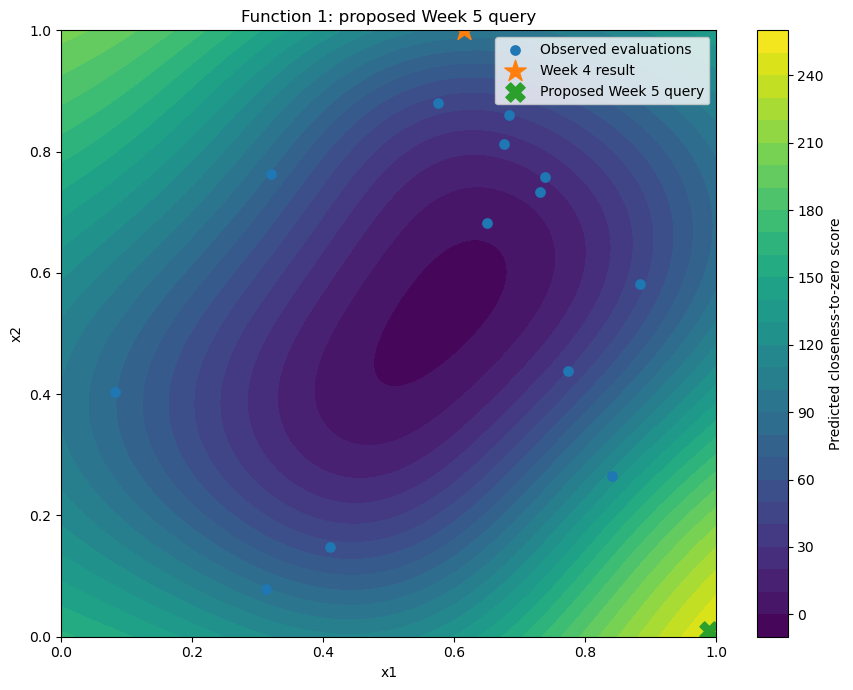

In [2]:
# ------------------------------------------------------------
# 9. Visualise the Week 5 model and proposal
# ------------------------------------------------------------

grid_size = 180

x1_values = np.linspace(0, 1, grid_size)
x2_values = np.linspace(0, 1, grid_size)

X1_grid, X2_grid = np.meshgrid(
    x1_values,
    x2_values
)

grid_points = np.column_stack([
    X1_grid.ravel(),
    X2_grid.ravel()
])

grid_mean, grid_std = gp.predict(
    grid_points,
    return_std=True
)

grid_mean = grid_mean.reshape(X1_grid.shape)

plt.figure(figsize=(9, 7))

contour = plt.contourf(
    X1_grid,
    X2_grid,
    grid_mean,
    levels=30
)

plt.colorbar(
    contour,
    label="Predicted closeness-to-zero score"
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=45,
    label="Observed evaluations"
)

plt.scatter(
    week4_x[0, 0],
    week4_x[0, 1],
    marker="*",
    s=260,
    label="Week 4 result"
)

plt.scatter(
    week5_query[0],
    week5_query[1],
    marker="X",
    s=190,
    label="Proposed Week 5 query"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: proposed Week 5 query")
plt.legend()
plt.tight_layout()
plt.show()